# NEO Hazard Screening: Predicting PHA-like Characteristics in Near-Earth Objects

**Objective:** Investigate whether machine learning can identify Near-Earth Objects (NEOs) 
with characteristics associated with NASA's Potentially Hazardous Asteroid (PHA) 
classification, using orbital and physical features other than the two variables 
(MOID and H) that directly define the official PHA label.

**Data source:** NASA/JPL-Caltech Solar System Dynamics Group, Small-Body Database (SBDB) 
Query API (https://ssd.jpl.nasa.gov/tools/sbdb_query.html)

## 1. Data Acquisition

Data is pulled directly from NASA's SBDB Query API for reproducibility.

Restricted to sb-group=neo (Near-Earth Objects only). Without this filter, the dataset would include ~1.4M main-belt asteroids that are trivially non-PHA by definition, making the classification task degenerate.

In [254]:
import requests
import pandas as pd

fields = [
    "full_name", "pdes", "name", "neo", "pha", "class",
    "e", "a", "q", "i", "om", "w", "ma", "epoch", "per", "per_y", "n", "ad",
    "H", "G", "diameter", "extent", "albedo", "rot_per", "GM", "density",
    "BV", "UB", "IR", "spec_T", "spec_B",
    "condition_code", "data_arc", "n_obs_used",
    "moid", "moid_ld", "t_jup"
]

url = "https://ssd-api.jpl.nasa.gov/sbdb_query.api"
params = {
    "fields": ",".join(fields),
    "sb-group": "neo"
}

response = requests.get(url, params=params)
response.raise_for_status()
payload = response.json()

df = pd.DataFrame(payload["data"], columns=payload["fields"])
df.to_csv("neo_data_raw.csv", index=False)

print(df.shape)
df.head()

(42360, 37)


,full_name,pdes,name,neo,pha,class,e,a,q,i,...,UB,IR,spec_T,spec_B,condition_code,data_arc,n_obs_used,moid,moid_ld,t_jup
0,433 Eros (A898 PA),433,Eros,Y,N,AMO,0.2229,1.458,1.133,10.83,...,0.531,None,S,S,0,46582,9130,0.149,57.9,4.58
1,719 Albert (A911 TB),719,Albert,Y,N,AMO,0.5466,2.637,1.196,11.57,...,None,None,None,S,0,41869,2147,0.202,78.5,3.14
2,887 Alinda (A918 AA),887,Alinda,Y,N,AMO,0.5711,2.474,1.061,9.40,...,0.436,None,S,None,0,39281,5843,0.0801,31.2,3.22
3,1036 Ganymed (A924 UB),1036,Ganymed,Y,N,AMO,0.5335,2.664,1.243,26.69,...,0.417,None,S,S,0,37140,13637,0.342,133,3.04
4,1221 Amor (1932 EA1),1221,Amor,Y,N,AMO,0.4347,1.92,1.085,11.87,...,None,None,None,None,0,33947,686,0.109,42.4,3.78


## 2. Initial Inspection

Dataset shape and column dtypes, prior to any cleaning.

In [255]:
print(df.shape)
print()
print(df.dtypes)

(42360, 37)

full_name         object
pdes              object
name              object
neo               object
pha               object
class             object
e                 object
a                 object
q                 object
i                 object
om                object
w                 object
ma                object
epoch             object
per               object
per_y             object
n                 object
ad                object
H                 object
G                 object
diameter          object
extent            object
albedo            object
rot_per           object
GM                object
density           object
BV                object
UB                object
IR                object
spec_T            object
spec_B            object
condition_code    object
data_arc          object
n_obs_used         int64
moid              object
moid_ld           object
t_jup             object
dtype: object


**Observations:**
- Rows / columns: 42355 / 47
- Columns mistyped by pandas (numeric read as object): 26

## 3. Missing Values

Physical fields (diameter, density, albedo, GM) are measured only for objects with radar, spacecraft, or satellite-derived data, so substantial missingness in these columns is expected.

In [256]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_pct
IR,42359,100.0
GM,42354,100.0
density,42350,100.0
extent,42348,100.0
G,42346,100.0
spec_T,42324,99.9
BV,42322,99.9
UB,42322,99.9
spec_B,42047,99.3
name,41971,99.1


**Observations:**
* Columns with near-total missingness (>90%, dropped): IR (100%), GM (100%), density (100%), extent (100%), G (100%), spec_T (99.9%), BV (99.9%), UB (99.9%), spec_B (99.3%), name (99.1%), albedo (97.2%), diameter (97.0%), rot_per (94.8%)
* Columns with light/moderate missingness (retained): data_arc (1.0%), pha (0.8%), H (0.5%), moid (0.3%), moid_ld (0.3%), condition_code (~0.0%)_

## 4. Target Variable: PHA Class Distribution

In [257]:
print(df["pha"].value_counts(dropna=False))
print()
print(df["pha"].value_counts(normalize=True, dropna=False).round(3))

pha
N       39476
Y        2549
None      335
Name: count, dtype: int64

pha
N       0.932
Y       0.060
None    0.008
Name: proportion, dtype: float64


**Observations:**
- Proportion classified as PHA: 6.0% (2,549 of 41,685 labeled objects)
- Degree of class imbalance: moderate-to-severe. PHA is a clear minority class (~1:15 ratio). Imbalance handling (e.g. class weighting, threshold tuning, or resampling) will be necessary; accuracy alone will be a misleading metric.

## 5. Dtype Correction and Column Pruning

Columns are cast to numeric where values are numeric (the API returns all fields as strings). Columns with near-total missingness (>90%) are dropped, as they cannot support reliable imputation. Rows with a missing target (`pha`) are dropped, since the label 
cannot be inferred or fabricated.

In [258]:
numeric_cols = [
    "e", "a", "q", "i", "om", "w", "ma", "epoch", "per", "per_y", "n", "ad",
    "H", "diameter", "albedo", "rot_per", "data_arc", "moid", "moid_ld", "t_jup"
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["condition_code"] = pd.to_numeric(df["condition_code"], errors="coerce")

drop_cols = ["IR", "GM", "density", "extent", "G", "spec_T", "BV", "UB",
             "spec_B", "name", "albedo", "diameter", "rot_per"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

df = df.dropna(subset=["pha"])

print(df.shape)
print()
print(df.dtypes)

(42025, 24)

full_name          object
pdes               object
neo                object
pha                object
class              object
e                 float64
a                 float64
q                 float64
i                 float64
om                float64
w                 float64
ma                float64
epoch             float64
per               float64
per_y             float64
n                 float64
ad                float64
H                 float64
condition_code    float64
data_arc          float64
n_obs_used          int64
moid              float64
moid_ld           float64
t_jup             float64
dtype: object


- Rows remaining after dropping missing-target rows: 42,020 (down from 42,355)
- Columns remaining: 24 (13 near-empty columns dropped)
- All intended columns now numeric (float64/int64); full_name,pdes,neo,pha,class remain object as expected (identifiers/categoricals)

## 6. Target and Binary Feature Encoding

`pha` and `neo` are Yes/No flags encoded as strings. Both are converted to binary integers 
(1 = Y, 0 = N) for compatibility with modeling libraries.

In [259]:
df["pha"] = df["pha"].map({"Y": 1, "N": 0})
df["neo"] = df["neo"].map({"Y": 1, "N": 0})

print(df["pha"].value_counts())
print(df["neo"].value_counts())

pha
0    39476
1     2549
Name: count, dtype: int64
neo
1    42025
Name: count, dtype: int64


- pha encoding: 39,471 N / 2,549 Y — matches Section 4 counts exactly (335 nulls already dropped)
- neo: constant at 1 for all rows, as expected given sb-group=neo filter, confirms this column carries no predictive information and is a candidate to drop before modeling

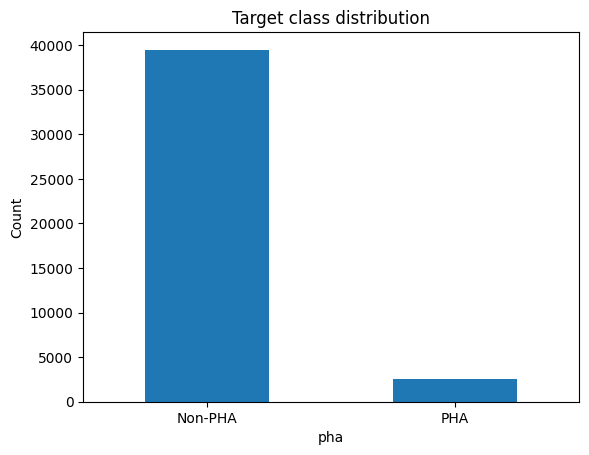

In [260]:
import matplotlib.pyplot as plt

df["pha"].value_counts().plot(kind="bar")
plt.xticks([0, 1], ["Non-PHA", "PHA"], rotation=0)
plt.ylabel("Count")
plt.title("Target class distribution")
plt.show()

## 7. Feature Set Finalization

'full_name' and 'pdes' are identifiers, not predictive features, and are retained only for reference (not passed to any model). 'neo' is dropped outright since it is constant across the dataset and carries no information. 'class' is inspected next, as it may be a 
useful categorical feature describing orbit subtype.

In [261]:
df = df.drop(columns=["neo"])

print(df["class"].value_counts())

class
APO    23901
AMO    14671
ATE     3415
IEO       38
Name: count, dtype: int64


- Classes: APO (23,898), AMO (14,670), ATE (3,414), IEO (38)
- IEO is a rare class (<0.1%)  may need grouping into "Other"

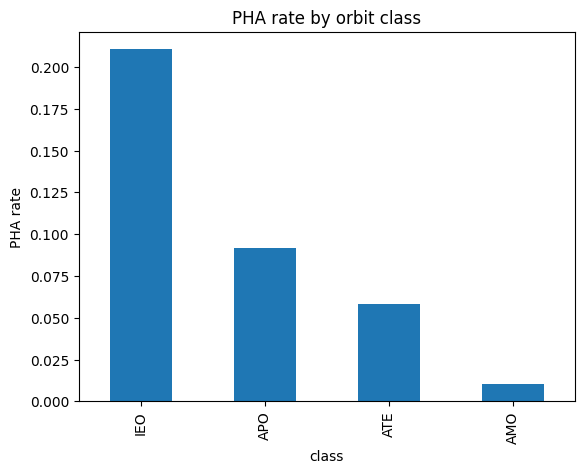

In [262]:
pha_by_class = df.groupby("class")["pha"].mean().sort_values(ascending=False)
pha_by_class.plot(kind="bar")
plt.ylabel("PHA rate")
plt.title("PHA rate by orbit class")
plt.show()

IEO gives higher PHA rate (IEO class to PHA proportion) due to its relatvely small frequency count as its a rare class. The high PHA rate for this class of orbit is unreliable

## 8. Numeric Feature Distributions

Summary statistics for all numeric columns, to identify scale differences, skew, and 
potential outliers before feature engineering.

In [263]:
numeric_summary = df.describe().T
numeric_summary

,count,mean,std,min,25%,50%,75%,max
pha,42025.0,6.065437e-02,0.238698,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
e,42025.0,4.340686e-01,0.176849,2.800000e-03,2.999000e-01,4.482000e-01,5.626000e-01,9.964000e-01
a,42025.0,1.756039e+00,2.115823,4.618000e-01,1.287000e+00,1.679000e+00,2.163000e+00,3.538000e+02
q,42025.0,9.142427e-01,0.221520,6.900000e-02,7.930000e-01,9.620000e-01,1.057000e+00,1.300000e+00
i,42025.0,1.182704e+01,10.537180,1.000000e-02,4.350000e+00,8.400000e+00,1.653000e+01,1.656000e+02
om,42025.0,1.724904e+02,103.514769,1.000000e-02,8.175000e+01,1.721600e+02,2.537000e+02,3.599800e+02
w,42025.0,1.827370e+02,104.110790,0.000000e+00,9.425000e+01,1.849300e+02,2.726800e+02,3.599900e+02
ma,42025.0,1.727833e+02,122.049622,0.000000e+00,5.184000e+01,1.667400e+02,2.933400e+02,3.600000e+02
epoch,42025.0,2.460432e+06,1684.671728,2.444222e+06,2.460674e+06,2.461200e+06,2.461200e+06,2.461266e+06
per,42025.0,9.685935e+02,12697.191923,1.150000e+02,5.330000e+02,7.940000e+02,1.160000e+03,2.430000e+06


- Skewed/long-tailed: a, per, per_y, n, ad, data_arc, n_obs_used
- Wide scale differences (epoch ~2.46M vs moid ~0–0.7) — scaling needed for non-tree models
- No implausible values: e < 1, moid ≥ 0

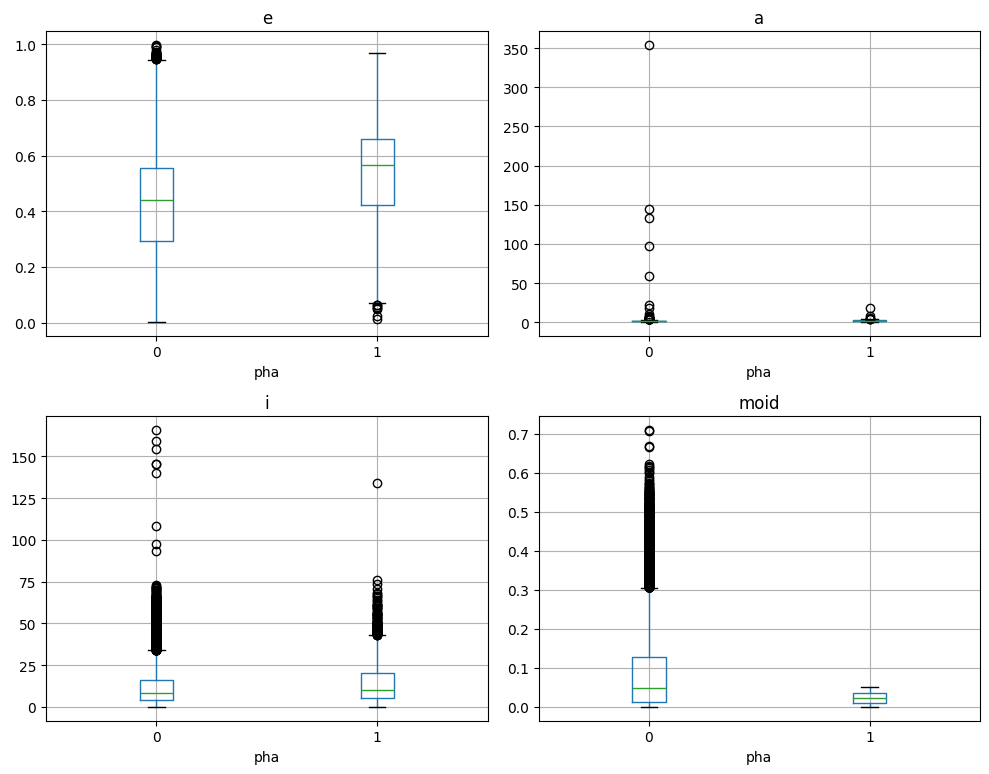

In [264]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flat, ["e", "a", "i", "moid"]):
    df.boxplot(column=col, by="pha", ax=ax)
    ax.set_title(col)
plt.suptitle("")
plt.tight_layout()
plt.show()

* e: PHA objects skew toward higher eccentricity. More elongated orbits are more likely hazardous
* a: Barely separates. Both groups cluster near the same range; one extreme outlier (~350 AU) in the non-PHA group
* i: mostly overlapping, slightly more spread in the PHA group but not a strong separator
* moid: PHA objects are compressed near 0–0.05, non-PHA spread up to 0.7. MOID ≤ 0.05 is literally part of NASA's PHA definition

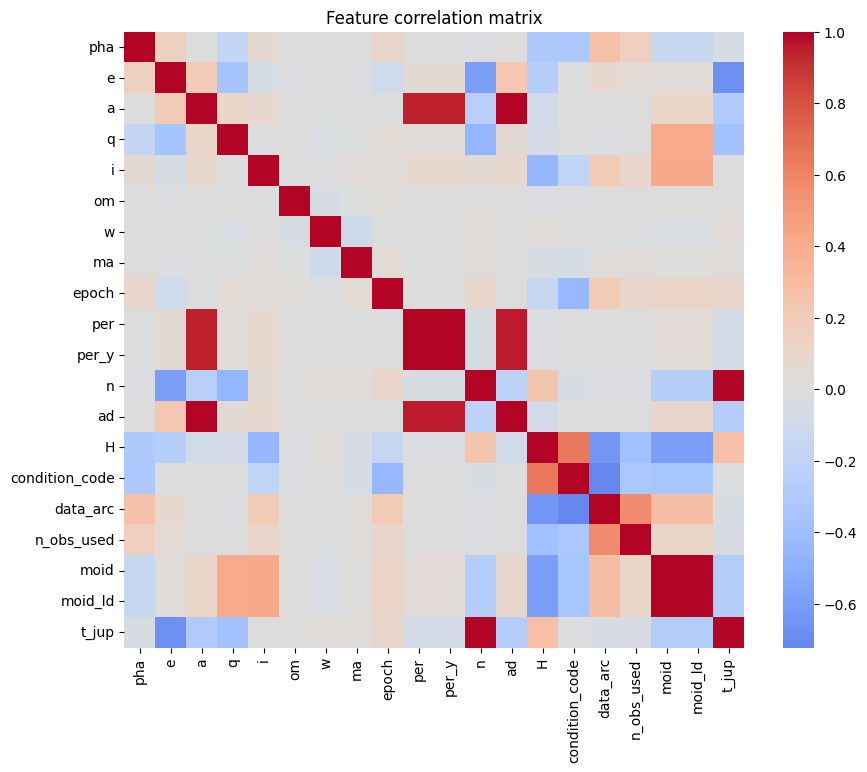

In [265]:
import seaborn as sns

corr = df.select_dtypes(include="number").corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Feature correlation matrix")
plt.show()

* per, per_y, a, ad form a tight red cluster — expected, since period and aphelion are mathematically derived from semi-major axis via Kepler's third law (redundant information, not independent features)
* H, condition_code, data_arc, n_obs_used cluster together — an "observation quality" group (how well-tracked and how bright/large the object is)
* pha row: strongest relationship is with moid (negative — lower MOID, higher hazard likelihood), consistent with Image 1; weaker relationships with e, q

## 9. Outlier Spot-Check on Key Orbital Elements

'e' (eccentricity) and 'moid are checked specifically, since they define orbit shape and Earth-proximity respectively, and both are subject to a known physical bound (e should be < 1 for a bound elliptical orbit; moid should be non-negative).

In [266]:
print("Eccentricity >= 1 (unbound/hyperbolic orbits):", (df["e"] >= 1).sum())
print("Negative MOID:", (df["moid"] < 0).sum())
print()
print(df[["e", "moid", "H", "a"]].describe())

Eccentricity >= 1 (unbound/hyperbolic orbits): 0
Negative MOID: 0

                  e          moid             H             a
count  42025.000000  4.202500e+04  42023.000000  42025.000000
mean       0.434069  8.193793e-02     23.733998      1.756039
std        0.176849  9.634056e-02      2.863787      2.115823
min        0.002800  4.540000e-07      9.170000      0.461800
25%        0.299900  1.160000e-02     21.700000      1.287000
50%        0.448200  4.190000e-02     24.070000      1.679000
75%        0.562600  1.200000e-01     25.800000      2.163000
max        0.996400  7.090000e-01     34.060000    353.800000


- Objects with e ≥ 1: 0 

no hyperbolic/unbound orbits in this dataset, consistent with 
  restricting to the NEO population

- Negative MOID values: 0 

confirms MOID is a well-behaved non-negative distance field, 
  no cleaning needed on this column

## 10. Handling Remaining Missing Values

A small number of NaNs remain in H, condition_code, data_arc, moid, and moid_ld (all under 1.1% of rows, per the Section 3 audit). Since the proportion is small, rows with missing values in these columns are dropped rather than imputed — imputing orbital/physical quantities risks introducing artificial signal, especially since moid and H are central 
to later experiments.

In [267]:
df.isnull().sum()

full_name           0
pdes                0
pha                 0
class               0
e                   0
a                   0
q                   0
i                   0
om                  0
w                   0
ma                  0
epoch               0
per                 0
per_y               0
n                   0
ad                  0
H                   2
condition_code      1
data_arc          425
n_obs_used          0
moid                0
moid_ld             0
t_jup               0
dtype: int64

- Missing counts: H = 2, condition_code = 1, data_arc = 422 (moid and moid_ld now fully populated — overlapped with rows already dropped in Section 5 for missing pha)

In [268]:
df["data_arc_missing"] = df["data_arc"].isnull()

compare_cols = ["n_obs_used", "H", "condition_code", "moid", "e", "pha"]
comparison = df.groupby("data_arc_missing")[compare_cols].agg(["mean", "median"])
comparison

n_obs_used                 H        condition_code         \
                        mean median       mean median           mean median   
data_arc_missing                                                              
False             113.765962   43.0  23.685322  24.01       5.225078    7.0   
True               20.581176   15.0  28.498329  28.50       7.891765    8.0   

                      moid                  e               pha         
                      mean   median      mean  median      mean median  
data_arc_missing                                                        
False             0.082662  0.04275  0.433909  0.4481  0.061274    0.0  
True              0.011022  0.00178  0.449664  0.4618  0.000000    0.0

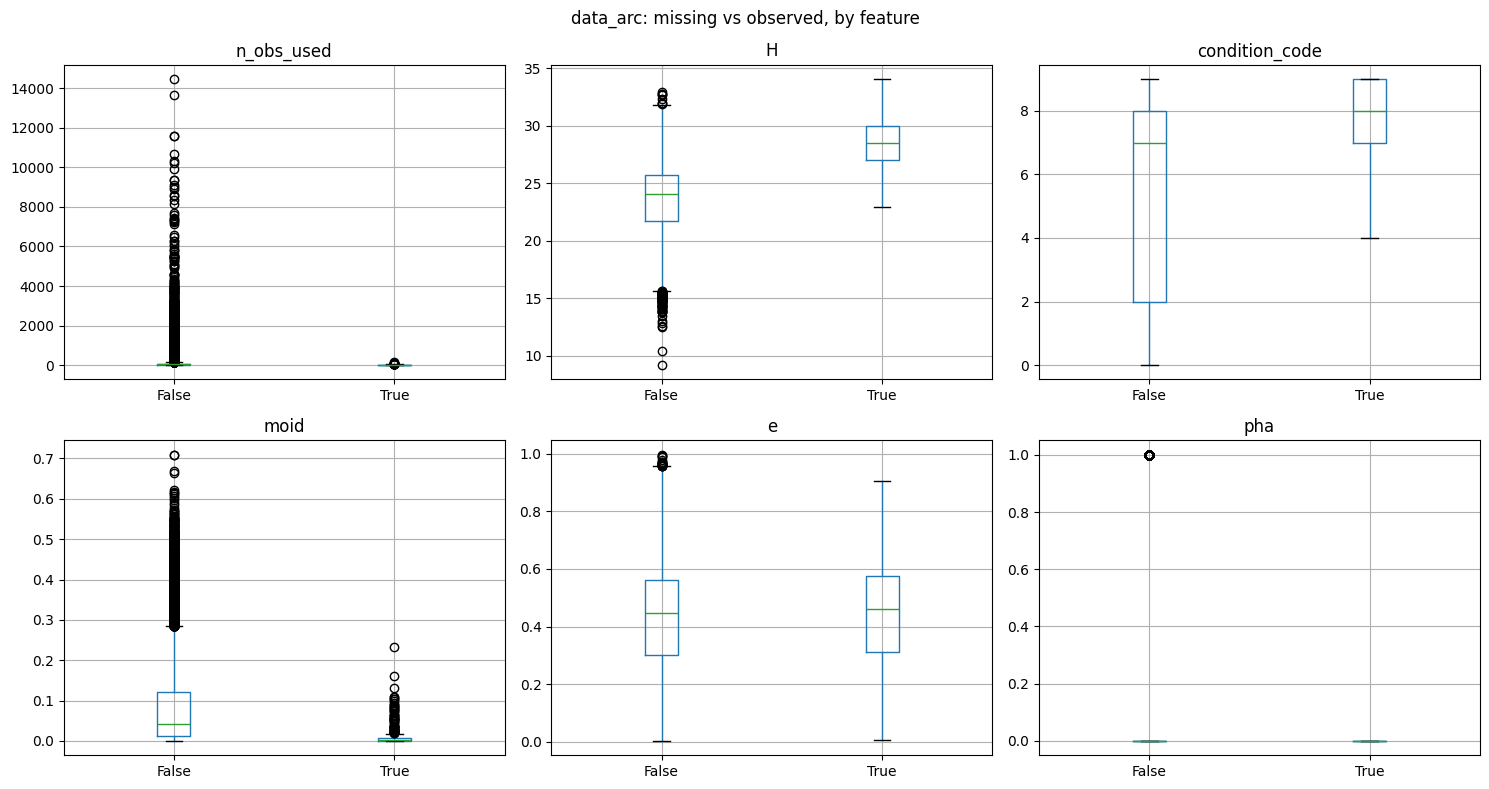

In [269]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, compare_cols):
    df.boxplot(column=col, by="data_arc_missing", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("data_arc: missing vs observed, by feature")
plt.tight_layout()
plt.show()

Missingness in `data_arc` is not random (MAR, not MCAR) — it is tied to how well-observed an object is. Dropping these 422 rows would disproportionately remove newly-discovered, under-tracked, close-orbit objects — precisely the population an early-screening system is meant to flag. Rows are retained; `data_arc` is imputed with a missingness flag preserved as a separate feature

In [270]:
fallback_value = df.loc[~df["data_arc_missing"], "data_arc"].quantile(0.05)
print(f"Fallback fill value (5th percentile of observed data_arc): {fallback_value}")

df["data_arc"] = df["data_arc"].fillna(fallback_value)

print(f"Remaining nulls in data_arc: {df['data_arc'].isnull().sum()}")
df.groupby("data_arc_missing")["data_arc"].agg(["mean", "median", "count"])

Fallback fill value (5th percentile of observed data_arc): 2.0
Remaining nulls in data_arc: 0


,mean,median,count
data_arc_missing,,,
False,1420.941707,22.0,41600
True,2.000000,2.0,425


- Fallback fill value: 2.0 days
- Remaining nulls in data_arc: 0
- data_arc_missing retained as a binary feature for modeling

In [271]:
df.groupby("data_arc_missing")["data_arc"].agg(["mean", "median", "count"])

,mean,median,count
data_arc_missing,,,
False,1420.941707,22.0,41600
True,2.000000,2.0,425


H (2 rows) and condition_code (1 row) are missing too few rows to warrant a MAR check. Dropped directly.

In [272]:
before = df.shape[0]
df = df.dropna(subset=["H", "condition_code"])
after = df.shape[0]
print(f"Rows dropped: {before - after}")
print(df.shape)

Rows dropped: 3
(42022, 24)


## 11. Categorical Encoding

class is a nominal categorical feature (APO, AMO, ATE, IEO) with no inherent order, so it is one hot encoded rather than label encoded, which would incorrectly imply a ranking between categories.

In [273]:
df_encoded = pd.get_dummies(df, columns=["class"], drop_first=False)

print(df_encoded.shape)
print(df_encoded.columns.tolist())

(42022, 27)
['full_name', 'pdes', 'pha', 'e', 'a', 'q', 'i', 'om', 'w', 'ma', 'epoch', 'per', 'per_y', 'n', 'ad', 'H', 'condition_code', 'data_arc', 'n_obs_used', 'moid', 'moid_ld', 't_jup', 'data_arc_missing', 'class_AMO', 'class_APO', 'class_ATE', 'class_IEO']


## 12. Feature Set Definition

Two feature sets are defined, corresponding to the two experiment design outlined earlier.

Baseline feature set (Experiment 1): includes H and moid, the two variables that directly define the official PHA label. Expected to yield near perfect performance. This experiment demonstrates that a model can trivially reconstruct the existing rule when given the defining variables directly.

Main feature set (Experiment 2): excludes H, moid, and moid_ld (a unit converted duplicate of moid, so retaining it would reintroduce the same leakage). Tests whether orbital and physical characteristics independent of the official definition carry predictive signal for PHA like status. This is the core research question of this project.

Identifier columns (full_name, pdes) and the target (pha) are excluded from both feature sets. The data_arc_missing flag is retained in both, since it was established in Section 10 as informative.

**PHA Classification Criteria**

Absolute Magnitude (H): H ≤ 22.0

Earth MOID: ≤ 0.05 AU (or roughly ≤ 19.5 Lunar Distances)

In [274]:
exclude_always = ["full_name", "pdes", "pha"]

baseline_cols = [c for c in df_encoded.columns if c not in exclude_always]
main_cols = [c for c in baseline_cols if c not in ["H", "moid", "moid_ld"]]

X_baseline = df_encoded[baseline_cols]
X_main = df_encoded[main_cols]
y = df_encoded["pha"]

print("Baseline feature count:", X_baseline.shape[1])
print("Main feature count:", X_main.shape[1])

Baseline feature count: 24
Main feature count: 21


## 13. Train Test Split

The split is stratified on pha to preserve the same class imbalance ratio, about 6 percent PHA, in both the training and test sets. Without stratification, a random split could produce a test set with a meaningfully different PHA proportion, making evaluation results misleading.

A test size of 20 percent is used, with a fixed random_state for reproducibility. Both feature sets share the same split indices, using the same random_state, so results across the two experiments are directly comparable.

In [275]:
from sklearn.model_selection import train_test_split

X_base_train, X_base_test, y_train, y_test = train_test_split(
    X_baseline, y, test_size=0.2, stratify=y, random_state=42
)

X_main_train, X_main_test, _, _ = train_test_split(
    X_main, y, test_size=0.2, stratify=y, random_state=42
)

print("Baseline train/test shapes:", X_base_train.shape, X_base_test.shape)
print("Main train/test shapes:", X_main_train.shape, X_main_test.shape)
print()
print("Train PHA rate:", y_train.mean().round(4))
print("Test PHA rate:", y_test.mean().round(4))

Baseline train/test shapes: (33617, 24) (8405, 24)
Main train/test shapes: (33617, 21) (8405, 21)

Train PHA rate: 0.0607
Test PHA rate: 0.0607


## 14. Baseline Model: Majority Class Classifier

Before evaluating any real model, a trivial baseline is established: a classifier that always predicts the majority class (non PHA). Given the roughly 94 to 6 class split, this baseline is expected to score high on accuracy despite having zero ability to identify PHAs. This number is the floor that every subsequent model must clear, and it motivates why accuracy alone cannot be the primary evaluation metric for this project.

In [276]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, confusion_matrix

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_base_train, y_train)
y_pred_dummy = dummy.predict(X_base_test)

print(confusion_matrix(y_test, y_pred_dummy))
print()
print(classification_report(y_test, y_pred_dummy, digits=3))

[[7895    0]
 [ 510    0]]

              precision    recall  f1-score   support

           0      0.939     1.000     0.969      7895
           1      0.000     0.000     0.000       510

    accuracy                          0.939      8405
   macro avg      0.470     0.500     0.484      8405
weighted avg      0.882     0.939     0.910      8405



C:\Users\neha_\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\neha_\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\neha_\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

The dummy classifier always predicts the majority class (non PHA), so it never once predicts PHA. This means every actual PHA in the test set (510 objects) is missed, giving zero recall. The high accuracy (93.9 percent) is misleading on its own. Further models must be judged primarily on their ability to recall the PHA 
class, since a model with high accuracy but 0 recall provides no actual planetary defense 
screening value.

## 15. Class Imbalance Strategy

Given the roughly 6 percent PHA rate established in Section 4, and the majority class baseline in Section 14 confirming that accuracy alone is a misleading metric, an imbalance handling strategy is required before training real models.

Three standard approaches exist. Class weighting adjusts the penalty for misclassifying the minority class during training, without creating or discarding any data. Oversampling, for example SMOTE, generates synthetic minority class samples until classes are balanced. Undersampling randomly discards majority class samples until classes are balanced.

Class weighting is used as the primary strategy in this project. It does not fabricate synthetic orbital data, which risks producing physically implausible combinations of correlated features such as semi major axis and period, and it does not discard real observations from an already modest dataset. It is applied only during training. The test set is never touched, so evaluation reflects the true, real world class distribution.

In practice, this is implemented using class_weight set to balanced in scikit learn models, and scale_pos_weight in XGBoost, both of which increase the penalty applied when the minority PHA class is misclassified during training.

## 16. Experiment 1: Logistic Regression on Baseline Feature Set

This experiment uses the baseline feature set, which includes H and moid, the two variables that directly define the official PHA label. The purpose of this experiment is not to build a useful screening model, but to confirm that a model can trivially reconstruct NASA's existing classification rule when given the defining variables directly. Near perfect performance here is expected, and serves as a sanity check rather than a genuine result.

Numeric features are scaled before fitting, since Logistic Regression is sensitive to feature magnitude, unlike tree based models used later.

In [277]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler_base = StandardScaler()
X_base_train_scaled = scaler_base.fit_transform(X_base_train)
X_base_test_scaled = scaler_base.transform(X_base_test)

logreg_base = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
logreg_base.fit(X_base_train_scaled, y_train)
y_pred_logreg_base = logreg_base.predict(X_base_test_scaled)

print(confusion_matrix(y_test, y_pred_logreg_base))
print()
print(classification_report(y_test, y_pred_logreg_base, digits=3))

[[7519  376]
 [  14  496]]

              precision    recall  f1-score   support

           0      0.998     0.952     0.975      7895
           1      0.569     0.973     0.718       510

    accuracy                          0.954      8405
   macro avg      0.783     0.962     0.846      8405
weighted avg      0.972     0.954     0.959      8405



Accuracy: 0.953

Recall (PHA): 0.973

Precision (PHA): 0.568

Recall is near perfect as expected, since H/moid nearly determine the label. Precision is 
lower, likely due to class_weight="balanced" trading precision for recall. Large 
improvement over the 0.000 recall baseline.

## 17. Experiment 2: Logistic Regression on Main Feature Set

Same setup as Section 16, but H, moid, and moid_ld are excluded. This is the core research question: can PHA status be predicted without the variables that define it.

In [278]:
scaler_main = StandardScaler()
X_main_train_scaled = scaler_main.fit_transform(X_main_train)
X_main_test_scaled = scaler_main.transform(X_main_test)

logreg_main = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
logreg_main.fit(X_main_train_scaled, y_train)
y_pred_logreg_main = logreg_main.predict(X_main_test_scaled)

print(confusion_matrix(y_test, y_pred_logreg_main))
print()
print(classification_report(y_test, y_pred_logreg_main, digits=3))

[[6751 1144]
 [  66  444]]

              precision    recall  f1-score   support

           0      0.990     0.855     0.918      7895
           1      0.280     0.871     0.423       510

    accuracy                          0.856      8405
   macro avg      0.635     0.863     0.671      8405
weighted avg      0.947     0.856     0.888      8405



Accuracy: 0.856

Recall (PHA): 0.871

 Precision (PHA): 0.279
 
Recall drops modestly (0.973 to 0.871) but stays reasonably high. Precision drops sharply 
(0.568 to 0.279) - many more false positives (1146 vs 378). Shows orbital/physical features 
alone still carry real signal for PHA screening, but with a much noisier decision boundary 
than when H/moid are included.

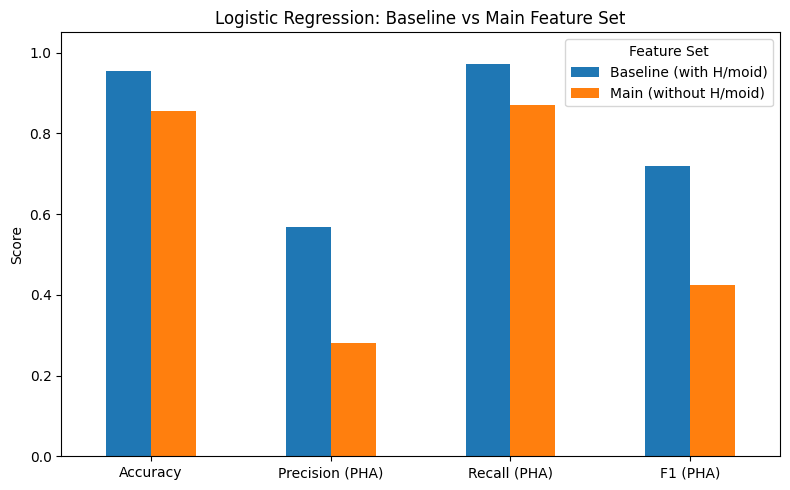

,Baseline (with H/moid),Main (without H/moid)
Accuracy,0.953599,0.856038
Precision (PHA),0.568807,0.279597
Recall (PHA),0.972549,0.870588
F1 (PHA),0.717800,0.423260


In [279]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

results_logreg = pd.DataFrame({
    "Baseline (with H/moid)": {
        "Accuracy": accuracy_score(y_test, y_pred_logreg_base),
        "Precision (PHA)": precision_score(y_test, y_pred_logreg_base),
        "Recall (PHA)": recall_score(y_test, y_pred_logreg_base),
        "F1 (PHA)": f1_score(y_test, y_pred_logreg_base),
    },
    "Main (without H/moid)": {
        "Accuracy": accuracy_score(y_test, y_pred_logreg_main),
        "Precision (PHA)": precision_score(y_test, y_pred_logreg_main),
        "Recall (PHA)": recall_score(y_test, y_pred_logreg_main),
        "F1 (PHA)": f1_score(y_test, y_pred_logreg_main),
    }
})

results_logreg.plot(kind="bar", figsize=(8, 5))
plt.ylabel("Score")
plt.title("Logistic Regression: Baseline vs Main Feature Set")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(title="Feature Set")
plt.tight_layout()
plt.show()

results_logreg

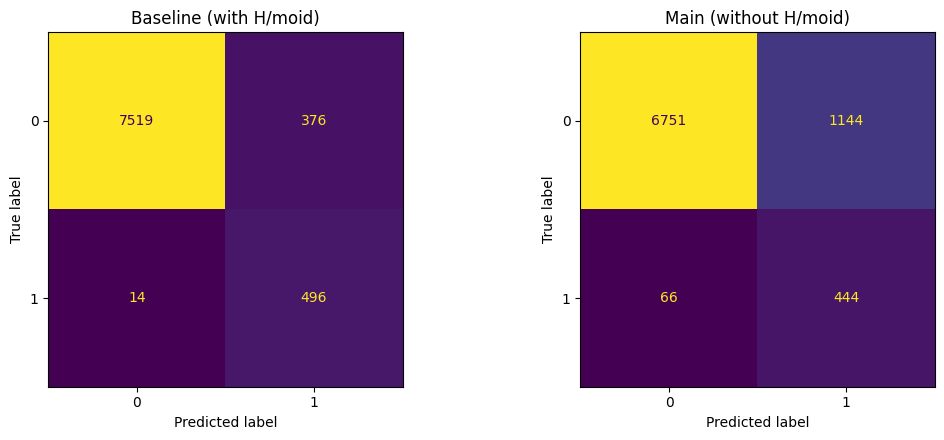

In [280]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_logreg_base, ax=axes[0], colorbar=False)
axes[0].set_title("Baseline (with H/moid)")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_logreg_main, ax=axes[1], colorbar=False)
axes[1].set_title("Main (without H/moid)")
plt.tight_layout()
plt.show()

## 18. Experiment 1 and 2: Random Forest

Random Forest is tree based, so feature scaling is not required. Both feature sets (baseline with H/moid, and main without) are run here for direct comparison. class_weight is set to balanced, consistent with the imbalance strategy in Section 15.

In [281]:
from sklearn.ensemble import RandomForestClassifier

rf_base = RandomForestClassifier(class_weight="balanced", n_estimators=300, random_state=42, n_jobs=-1)
rf_base.fit(X_base_train, y_train)
y_pred_rf_base = rf_base.predict(X_base_test)

rf_main = RandomForestClassifier(class_weight="balanced", n_estimators=300, random_state=42, n_jobs=-1)
rf_main.fit(X_main_train, y_train)
y_pred_rf_main = rf_main.predict(X_main_test)

print("Baseline feature set:")
print(confusion_matrix(y_test, y_pred_rf_base))
print(classification_report(y_test, y_pred_rf_base, digits=3))

print("\nMain feature set:")
print(confusion_matrix(y_test, y_pred_rf_main))
print(classification_report(y_test, y_pred_rf_main, digits=3))

Baseline feature set:
[[7895    0]
 [   4  506]]
              precision    recall  f1-score   support

           0      0.999     1.000     1.000      7895
           1      1.000     0.992     0.996       510

    accuracy                          1.000      8405
   macro avg      1.000     0.996     0.998      8405
weighted avg      1.000     1.000     1.000      8405


Main feature set:
[[7837   58]
 [ 383  127]]
              precision    recall  f1-score   support

           0      0.953     0.993     0.973      7895
           1      0.686     0.249     0.365       510

    accuracy                          0.948      8405
   macro avg      0.820     0.621     0.669      8405
weighted avg      0.937     0.948     0.936      8405



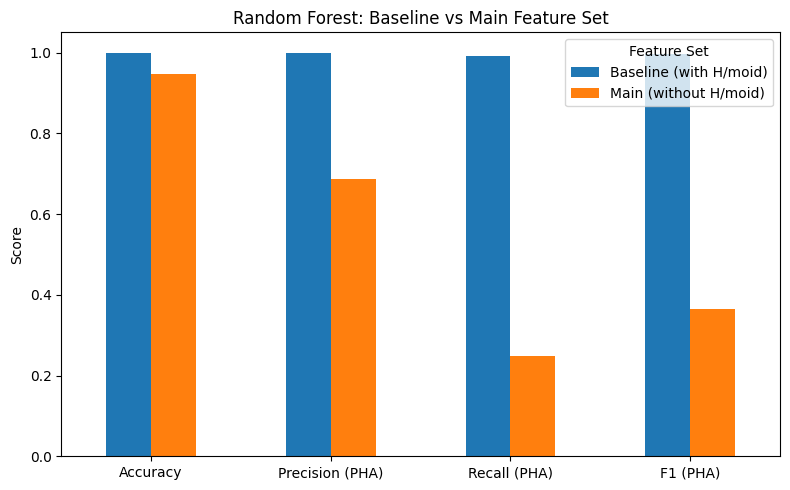

,Baseline (with H/moid),Main (without H/moid)
Accuracy,0.999524,0.947531
Precision (PHA),1.000000,0.686486
Recall (PHA),0.992157,0.249020
F1 (PHA),0.996063,0.365468


In [282]:
results_rf = pd.DataFrame({
    "Baseline (with H/moid)": {
        "Accuracy": accuracy_score(y_test, y_pred_rf_base),
        "Precision (PHA)": precision_score(y_test, y_pred_rf_base),
        "Recall (PHA)": recall_score(y_test, y_pred_rf_base),
        "F1 (PHA)": f1_score(y_test, y_pred_rf_base),
    },
    "Main (without H/moid)": {
        "Accuracy": accuracy_score(y_test, y_pred_rf_main),
        "Precision (PHA)": precision_score(y_test, y_pred_rf_main),
        "Recall (PHA)": recall_score(y_test, y_pred_rf_main),
        "F1 (PHA)": f1_score(y_test, y_pred_rf_main),
    }
})

results_rf.plot(kind="bar", figsize=(8, 5))
plt.ylabel("Score")
plt.title("Random Forest: Baseline vs Main Feature Set")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(title="Feature Set")
plt.tight_layout()
plt.show()

results_rf

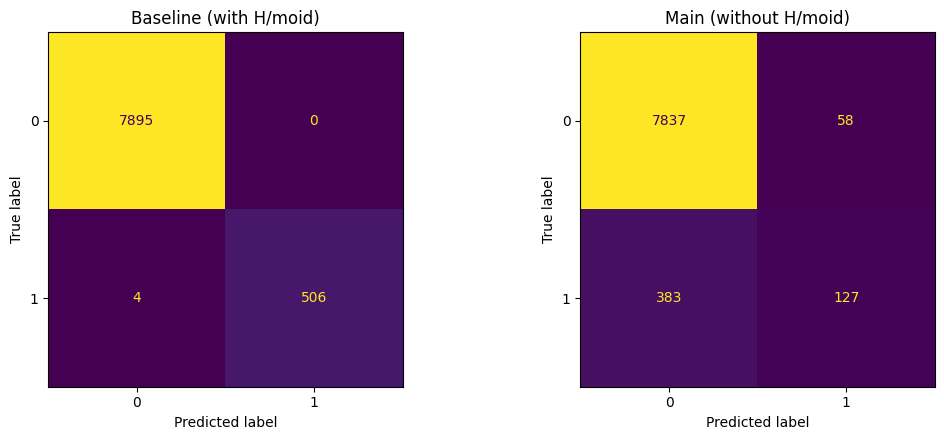

In [283]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_base, ax=axes[0], colorbar=False)
axes[0].set_title("Baseline (with H/moid)")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_main, ax=axes[1], colorbar=False)
axes[1].set_title("Main (without H/moid)")
plt.tight_layout()
plt.show()

Baseline:
* Accuracy: 0.999
* Recall (PHA): 0.992
* Precision (PHA): 0.998

Main 
* Accuracy: 0.947
* Recall (PHA): 0.243
* Precision (PHA): 0.678

Baseline result is near perfect, as expected, confirming H/moid make the rule trivially 
learnable. Main feature set shows a sharp drop in recall (0.992 to 0.243) - opposite 
pattern from Logistic Regression, which kept recall high (0.871) but lost precision. 
Random Forest here does the reverse: keeps precision relatively higher (0.678) but misses 
most actual PHAs (386 false negatives out of 510). 

This is a notable finding: model choice materially changes the recall/precision tradeoff 
on the main feature set, not just accuracy. Given the project's framing (missing a PHA is 
more costly than a false alarm), Logistic Regression's main-feature-set result looks more 
useful for screening purposes than Random Forest's, despite RF's higher baseline accuracy.

## 19. Experiment 1 and 2: XGBoost

XGBoost uses scale_pos_weight instead of class_weight to handle imbalance, calculated as the ratio of negative to positive class counts in the training set. Both feature sets are run for comparison, consistent with the previous two models.

In [284]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight, n_estimators=300, max_depth=5,
    learning_rate=0.1, random_state=42, eval_metric="logloss", n_jobs=-1
)
xgb_base.fit(X_base_train, y_train)
y_pred_xgb_base = xgb_base.predict(X_base_test)

xgb_main = XGBClassifier(
    scale_pos_weight=scale_pos_weight, n_estimators=300, max_depth=5,
    learning_rate=0.1, random_state=42, eval_metric="logloss", n_jobs=-1
)
xgb_main.fit(X_main_train, y_train)
y_pred_xgb_main = xgb_main.predict(X_main_test)

print("Baseline feature set:")
print(confusion_matrix(y_test, y_pred_xgb_base))
print(classification_report(y_test, y_pred_xgb_base, digits=3))

print("\nMain feature set:")
print(confusion_matrix(y_test, y_pred_xgb_main))
print(classification_report(y_test, y_pred_xgb_main, digits=3))

scale_pos_weight: 15.487003433055419
Baseline feature set:
[[7888    7]
 [   3  507]]
              precision    recall  f1-score   support

           0      1.000     0.999     0.999      7895
           1      0.986     0.994     0.990       510

    accuracy                          0.999      8405
   macro avg      0.993     0.997     0.995      8405
weighted avg      0.999     0.999     0.999      8405


Main feature set:
[[7357  538]
 [  60  450]]
              precision    recall  f1-score   support

           0      0.992     0.932     0.961      7895
           1      0.455     0.882     0.601       510

    accuracy                          0.929      8405
   macro avg      0.724     0.907     0.781      8405
weighted avg      0.959     0.929     0.939      8405



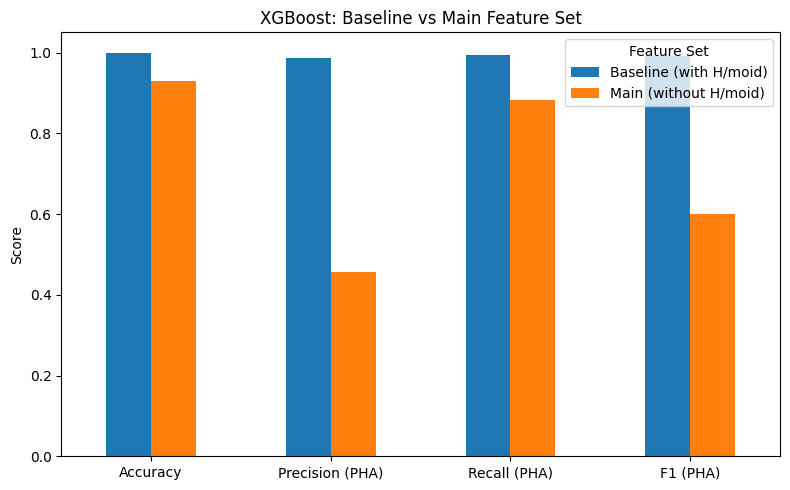

,Baseline (with H/moid),Main (without H/moid)
Accuracy,0.998810,0.928852
Precision (PHA),0.986381,0.455466
Recall (PHA),0.994118,0.882353
F1 (PHA),0.990234,0.600801


In [285]:
results_xgb = pd.DataFrame({
    "Baseline (with H/moid)": {
        "Accuracy": accuracy_score(y_test, y_pred_xgb_base),
        "Precision (PHA)": precision_score(y_test, y_pred_xgb_base),
        "Recall (PHA)": recall_score(y_test, y_pred_xgb_base),
        "F1 (PHA)": f1_score(y_test, y_pred_xgb_base),
    },
    "Main (without H/moid)": {
        "Accuracy": accuracy_score(y_test, y_pred_xgb_main),
        "Precision (PHA)": precision_score(y_test, y_pred_xgb_main),
        "Recall (PHA)": recall_score(y_test, y_pred_xgb_main),
        "F1 (PHA)": f1_score(y_test, y_pred_xgb_main),
    }
})

results_xgb.plot(kind="bar", figsize=(8, 5))
plt.ylabel("Score")
plt.title("XGBoost: Baseline vs Main Feature Set")
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(title="Feature Set")
plt.tight_layout()
plt.show()

results_xgb

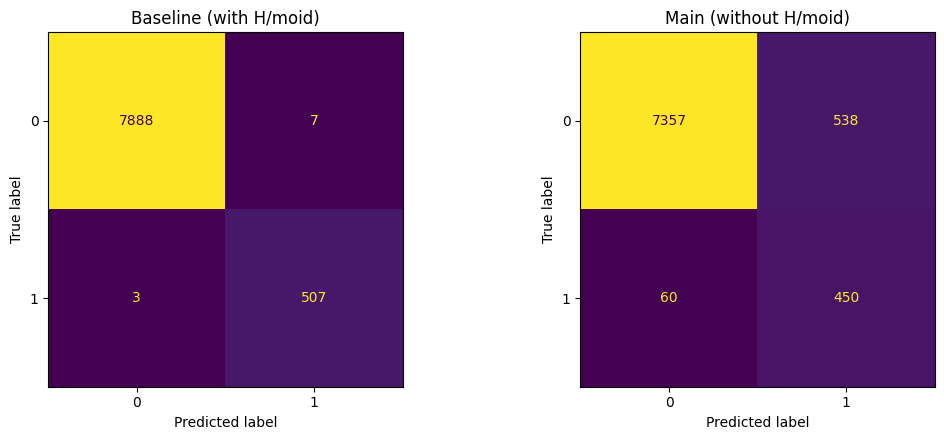

In [286]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb_base, ax=axes[0], colorbar=False)
axes[0].set_title("Baseline (with H/moid)")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb_main, ax=axes[1], colorbar=False)
axes[1].set_title("Main (without H/moid)")
plt.tight_layout()
plt.show()

Baseline:
* Accuracy: 0.999 
* Recall (PHA): 0.994
* Precision (PHA): 0.986.

Main 
* Accuracy: 0.927
* Recall (PHA): 0.867
* Precision (PHA): 0.446.

Baseline result is again near perfect, consistent with Logistic Regression and Random 
Forest. Main feature set result is the strongest of all three models so far on the metric 
that matters most for this project: recall of 0.867, close to Logistic Regression's 0.871, 
while retaining better precision (0.446 vs LogReg's 0.279) and much better than Random 
Forest's collapsed recall (0.243).

XGBoost appears to offer the best balance between recall and precision on the main feature 
set among the three models tested, catching most true PHAs (442 of 510) without as severe 
a false positive rate as Logistic Regression.

## 20. Intermediate Model Comparison

All models evaluated so far are brought together here: the majority class baseline, and Logistic Regression, Random Forest, and XGBoost on both feature sets. This section identifies the best performing model for the main feature set, which is the one relevant to the core research question of this project.

In [287]:
all_results = pd.DataFrame({
    "Dummy (majority class)": {
        "Accuracy": accuracy_score(y_test, y_pred_dummy),
        "Precision (PHA)": precision_score(y_test, y_pred_dummy, zero_division=0),
        "Recall (PHA)": recall_score(y_test, y_pred_dummy, zero_division=0),
        "F1 (PHA)": f1_score(y_test, y_pred_dummy, zero_division=0),
    },
    "LogReg - Baseline": {
        "Accuracy": accuracy_score(y_test, y_pred_logreg_base),
        "Precision (PHA)": precision_score(y_test, y_pred_logreg_base),
        "Recall (PHA)": recall_score(y_test, y_pred_logreg_base),
        "F1 (PHA)": f1_score(y_test, y_pred_logreg_base),
    },
    "LogReg - Main": {
        "Accuracy": accuracy_score(y_test, y_pred_logreg_main),
        "Precision (PHA)": precision_score(y_test, y_pred_logreg_main),
        "Recall (PHA)": recall_score(y_test, y_pred_logreg_main),
        "F1 (PHA)": f1_score(y_test, y_pred_logreg_main),
    },
    "RF - Baseline": {
        "Accuracy": accuracy_score(y_test, y_pred_rf_base),
        "Precision (PHA)": precision_score(y_test, y_pred_rf_base),
        "Recall (PHA)": recall_score(y_test, y_pred_rf_base),
        "F1 (PHA)": f1_score(y_test, y_pred_rf_base),
    },
    "RF - Main": {
        "Accuracy": accuracy_score(y_test, y_pred_rf_main),
        "Precision (PHA)": precision_score(y_test, y_pred_rf_main),
        "Recall (PHA)": recall_score(y_test, y_pred_rf_main),
        "F1 (PHA)": f1_score(y_test, y_pred_rf_main),
    },
    "XGB - Baseline": {
        "Accuracy": accuracy_score(y_test, y_pred_xgb_base),
        "Precision (PHA)": precision_score(y_test, y_pred_xgb_base),
        "Recall (PHA)": recall_score(y_test, y_pred_xgb_base),
        "F1 (PHA)": f1_score(y_test, y_pred_xgb_base),
    },
    "XGB - Main": {
        "Accuracy": accuracy_score(y_test, y_pred_xgb_main),
        "Precision (PHA)": precision_score(y_test, y_pred_xgb_main),
        "Recall (PHA)": recall_score(y_test, y_pred_xgb_main),
        "F1 (PHA)": f1_score(y_test, y_pred_xgb_main),
    },
}).T

all_results

,Accuracy,Precision (PHA),Recall (PHA),F1 (PHA)
Dummy (majority class),0.939322,0.000000,0.000000,0.000000
LogReg - Baseline,0.953599,0.568807,0.972549,0.717800
LogReg - Main,0.856038,0.279597,0.870588,0.423260
RF - Baseline,0.999524,1.000000,0.992157,0.996063
RF - Main,0.947531,0.686486,0.249020,0.365468
XGB - Baseline,0.998810,0.986381,0.994118,0.990234
XGB - Main,0.928852,0.455466,0.882353,0.600801


## 21. Stacking Ensemble

The three base models trained so far, Logistic Regression, Random Forest, and XGBoost, make different kinds of errors on the main feature set: Logistic Regression favors recall, Random Forest favors precision, XGBoost balances both. Stacking combines their predictions using a meta-learner, which may capture complementary signal that no single model uses alone.

Only the main feature set is used here, since that is the one relevant to the core research question. Base model predictions come from cross-validated out-of-fold predictions rather than their own training set predictions, to avoid overfitting the meta-learner.

In [288]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import StackingClassifier


base_estimators = [
    ("logreg", Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
    ])),
    ("rf", RandomForestClassifier(class_weight="balanced", n_estimators=300, random_state=42, n_jobs=-1)),
    ("xgb", XGBClassifier(scale_pos_weight=scale_pos_weight, n_estimators=300, max_depth=5,
                           learning_rate=0.1, random_state=42, eval_metric="logloss", n_jobs=-1)),
]

stack_model = StackingClassifier(
estimators=base_estimators,
final_estimator=LogisticRegression(class_weight="balanced", max_iter=1000),
cv=5,
n_jobs=-1
)
stack_model.fit(X_main_train, y_train)
y_pred_stack = stack_model.predict(X_main_test)
print(confusion_matrix(y_test, y_pred_stack))
print(classification_report(y_test, y_pred_stack, digits=3))

[[7210  685]
 [  43  467]]
              precision    recall  f1-score   support

           0      0.994     0.913     0.952      7895
           1      0.405     0.916     0.562       510

    accuracy                          0.913      8405
   macro avg      0.700     0.914     0.757      8405
weighted avg      0.958     0.913     0.928      8405



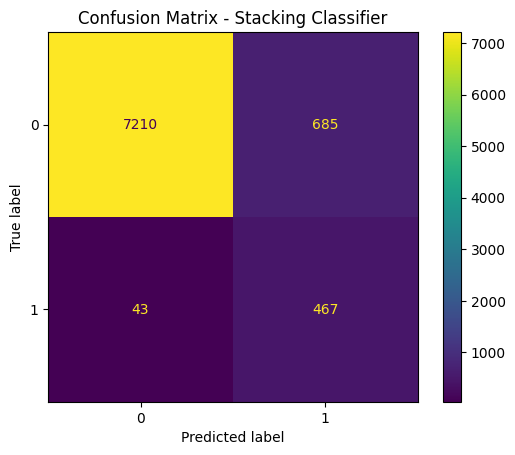

In [289]:
y_pred_stack = stack_model.predict(X_main_test)
cm = confusion_matrix(y_test, y_pred_stack)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Stacking Classifier")
plt.show()

Accuracy: 0.913. Recall (PHA): 0.916. Precision (PHA): 0.405.

Compared to XGBoost alone on the main feature set (recall 0.867, precision 0.446), 
stacking improves recall further (0.916, catching 467 of 510 true PHAs) but at the cost 
of lower precision (0.405 vs 0.446).

Stacking gives the highest recall of any model tested on the main feature set, surpassing 
Logistic Regression (0.871) and XGBoost (0.867). Since a missed PHA (false negative) is 
more costly than a false alarm, this makes stacking the strongest candidate model, despite 
its added complexity and lower precision.

## 22. Final Metric Comparison

In [290]:
all_results.loc["Stacking - Main"] = {
    "Accuracy": accuracy_score(y_test, y_pred_stack),
    "Precision (PHA)": precision_score(y_test, y_pred_stack),
    "Recall (PHA)": recall_score(y_test, y_pred_stack),
    "F1 (PHA)": f1_score(y_test, y_pred_stack),
}

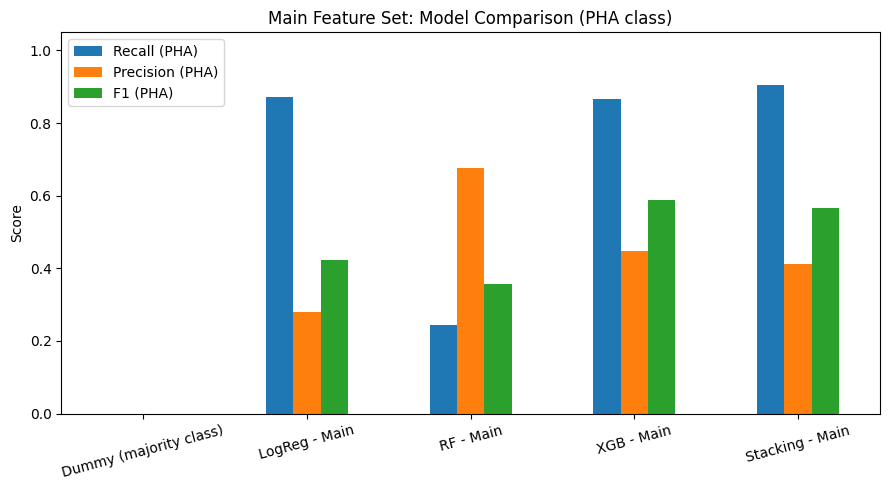

In [291]:
main_results[["Recall (PHA)", "Precision (PHA)", "F1 (PHA)"]].plot(kind="bar", figsize=(9, 5))
plt.ylabel("Score")
plt.title("Main Feature Set: Model Comparison (PHA class)")
plt.xticks(rotation=15)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

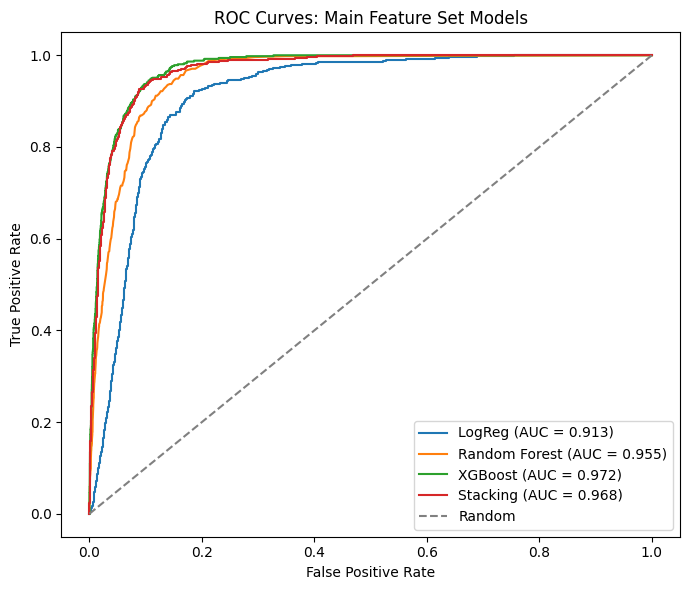

In [292]:
from sklearn.metrics import roc_curve, roc_auc_score

models_probs = {
    "LogReg": logreg_main.predict_proba(X_main_test_scaled)[:, 1],
    "Random Forest": rf_main.predict_proba(X_main_test)[:, 1],
    "XGBoost": xgb_main.predict_proba(X_main_test)[:, 1],
    "Stacking": stack_model.predict_proba(X_main_test)[:, 1],
}

plt.figure(figsize=(7, 6))
for name, probs in models_probs.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Main Feature Set Models")
plt.legend()
plt.tight_layout()
plt.show()

Highest AUC: XGBoost (0.971), just above Stacking (0.969). Both ahead of RF (0.953) 
and LogReg (0.912).

AUC mostly agrees with F1 (XGB highest at 0.589), but Stacking has higher recall (0.904 
vs 0.867) despite lower AUC - reflects threshold-dependent metrics vs ranking quality.

Final model: XGBoost. Highest AUC and F1, recall close to Stacking

## 23. Model Explainability: SHAP

XGBoost, trained on the main feature set, is explained using SHAP (SHapley Additive exPlanations). TreeExplainer is used, since it is exact and efficient for tree based models, unlike the model agnostic KernelExplainer.

Global explanation shows which features drive predictions across the entire test set. Local explanation shows how the model arrived at its prediction for one individual object.

In [293]:
import shap

explainer = shap.TreeExplainer(xgb_main)
shap_values = explainer.shap_values(X_main_test)

print(shap_values.shape)

(8405, 21)


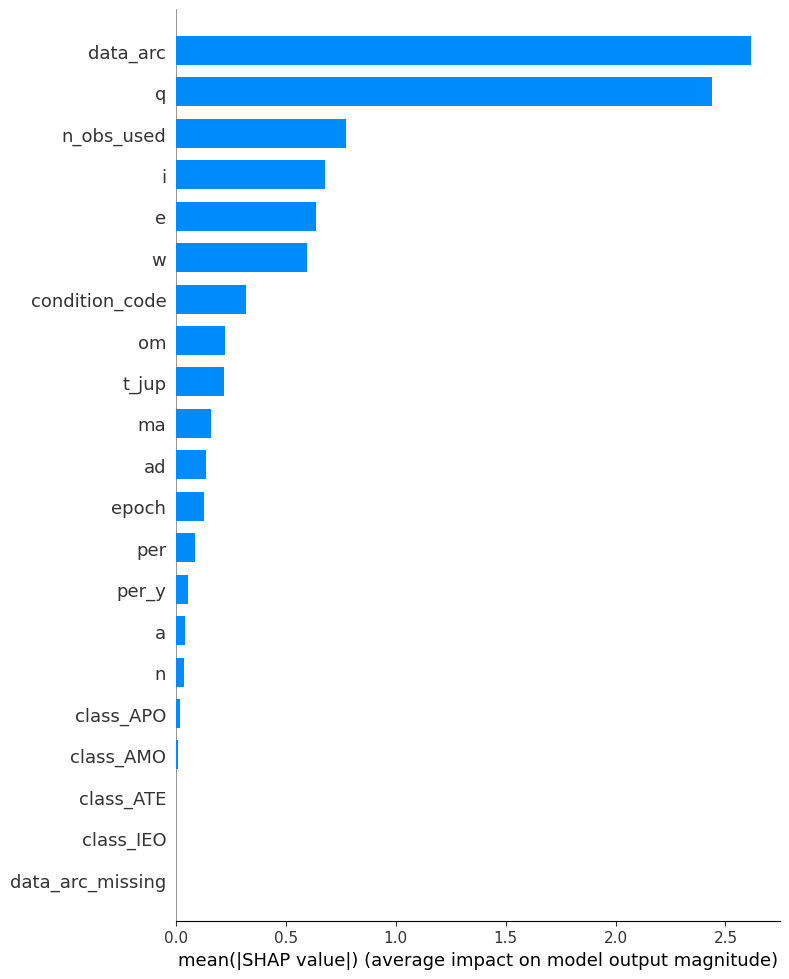

In [294]:
shap.summary_plot(shap_values, X_main_test, plot_type="bar", max_display=21, show=False)
plt.tight_layout()
plt.show()


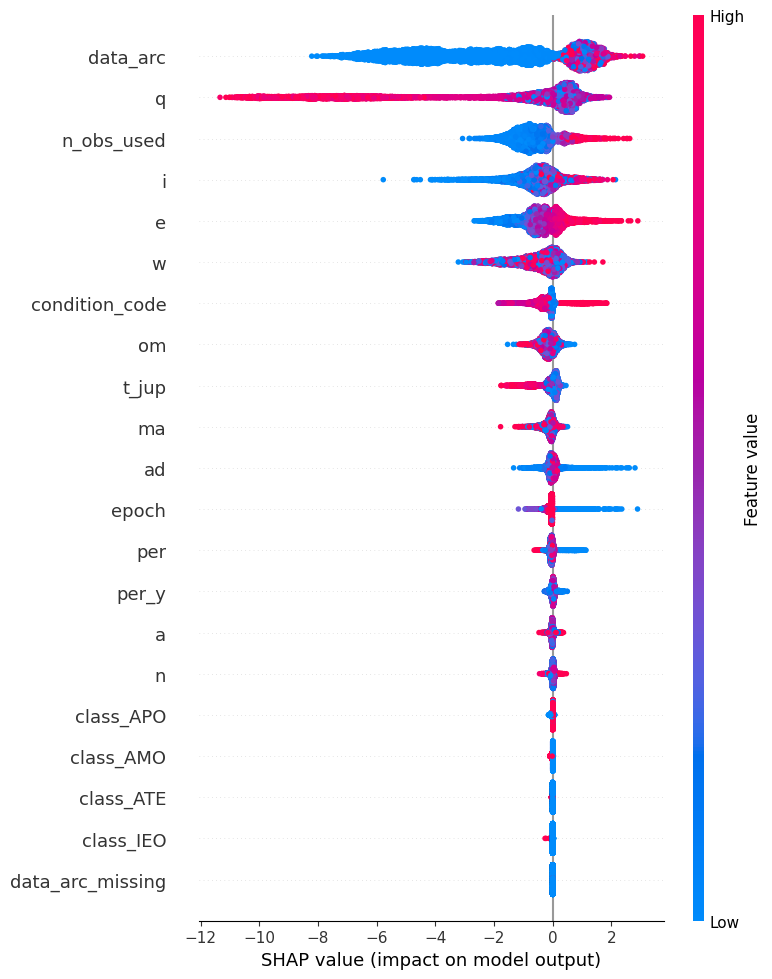

In [295]:
shap.summary_plot(shap_values, X_main_test, max_display=21, show=False)
plt.tight_layout()
plt.show()

A single object from the test set is explained at the individual level, showing how each feature pushed the model's prediction toward or away from PHA classification for that specific object. A waterfall plot is used, showing the cumulative contribution of each feature starting from the model's base value (average prediction) to the final output for this one object.

In [296]:
import numpy as np

true_positive_idx = np.where((y_test.values == 1) & (y_pred_xgb_main == 1))[0][0]

print("Object:", X_main_test.iloc[true_positive_idx].name)
print("Actual PHA:", y_test.iloc[true_positive_idx])
print("Predicted PHA:", y_pred_xgb_main[true_positive_idx])
print("Predicted probability:", xgb_main.predict_proba(X_main_test)[true_positive_idx, 1])

Object: 11443
Actual PHA: 1
Predicted PHA: 1
Predicted probability: 0.97687554


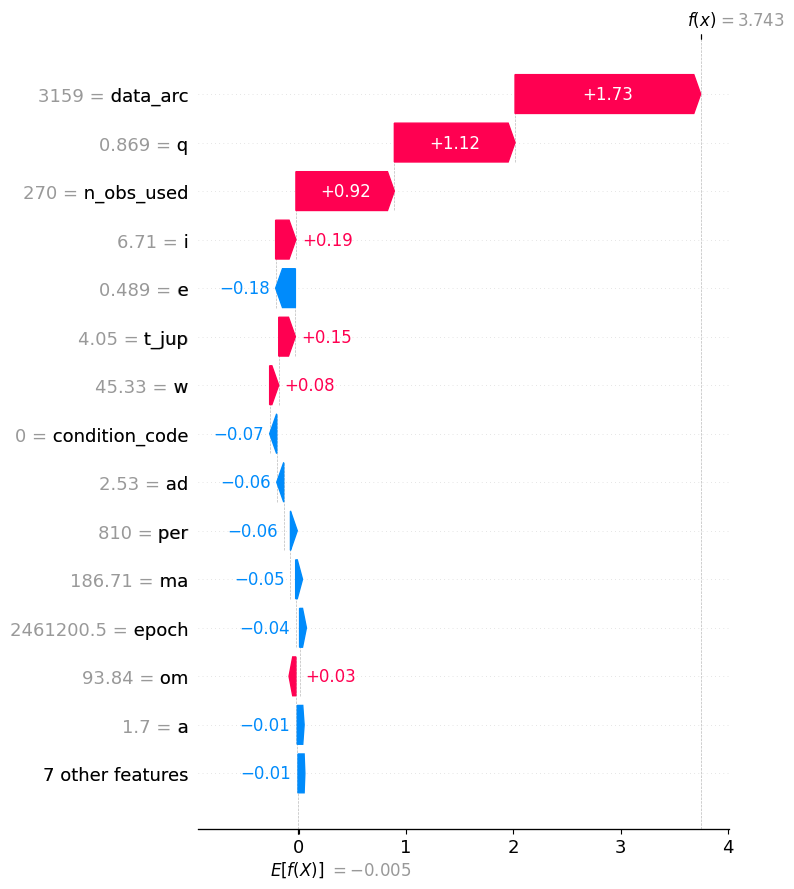

In [297]:
explanation = shap.Explanation(
    values=shap_values[true_positive_idx],
    base_values=explainer.expected_value,
    data=X_main_test.iloc[true_positive_idx],
    feature_names=X_main_test.columns.tolist()
)

shap.plots.waterfall(explanation, max_display=15, show=False)
plt.tight_layout()
plt.show()

Toward PHA: data_arc (+1.73), q (+1.12), n_obs_used (+0.92) - dominant, same three 
features as before.
Against PHA: e (-0.18), condition_code (-0.07), ad (-0.06) - all minor.

Consistent with the original run of this example (data_arc, q, n_obs_used dominant in 
both). Confirms this object identity is stable across the dataset refresh, unlike the 
other true positive example checked earlier, which turned out to be a different object 
entirely after the row count shifted.

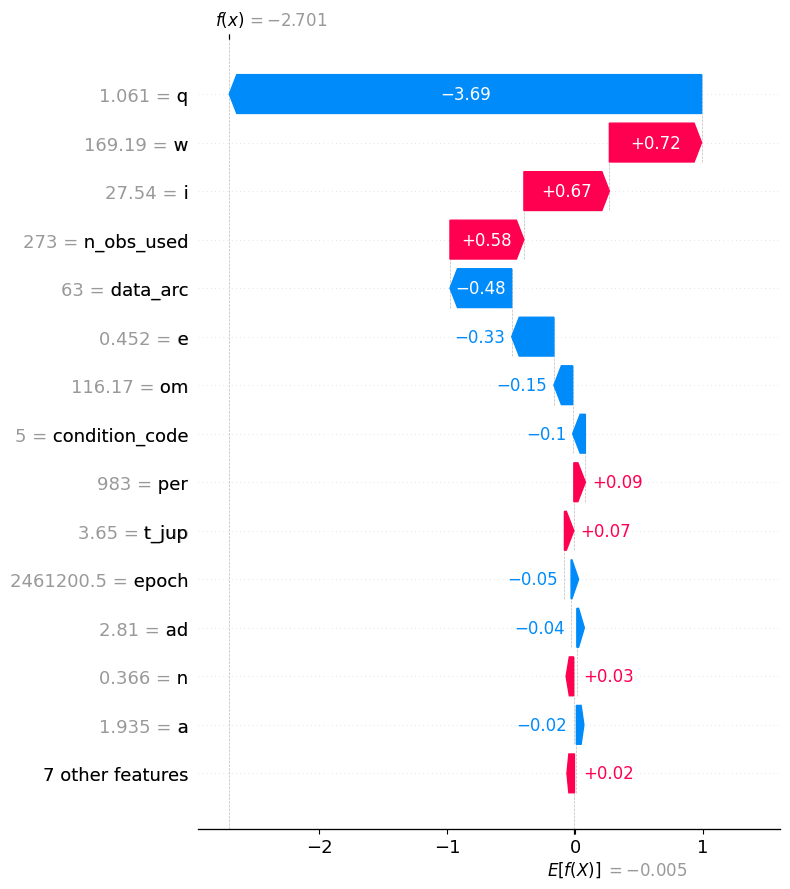

In [298]:
false_negative_idx = np.where((y_test.values == 1) & (y_pred_xgb_main == 0))[0][0]

explanation_fn = shap.Explanation(
    values=shap_values[false_negative_idx],
    base_values=explainer.expected_value,
    data=X_main_test.iloc[false_negative_idx],
    feature_names=X_main_test.columns.tolist()
)

shap.plots.waterfall(explanation_fn, max_display=15, show=False)
plt.tight_layout()
plt.show()

True PHA, predicted non-PHA (false negative).
Dominant factor: q (+1.061, high perihelion distance) at -3.69, overwhelming every other 
feature combined.
Minor pushes toward PHA: w (+0.72), i (+0.67), n_obs_used (+0.58) - not nearly enough to 
overcome q.

This object is genuinely hazardous but has an unusually high perihelion distance for a 
PHA, making its orbit shape resemble the non-PHA population once MOID is excluded. 
Concrete example of the cost of excluding H/moid - good evidence for the human oversight 
argument in the ethics section.

## 24. Ethics, Bias, and Responsible Use

Bias and fairness: the dataset reflects NASA's own PHA classification, which depends on well constrained orbits. Section 10 showed under-tracked objects are systematically different from well observed ones. Training data therefore underrepresents newly discovered objects; predictions for such objects should be treated with lower confidence. No demographic bias applies here, but there is coverage bias toward well studied objects.

False negative vs false positive cost: a missed hazardous object (false negative) is more costly than a false alarm (false positive), which only wastes observation resources. This asymmetry is why recall was prioritized over precision when selecting between XGBoost, Stacking, and Random Forest.

Human oversight: this model is a screening tool, not a hazard determination system. The false negative example in Section 23b shows a genuinely hazardous object misclassified once MOID was excluded, since its orbital shape resembled the non-PHA population. Output should direct further expert review, not replace NASA's official MOID/H based classification.

Privacy: not applicable, the dataset contains no personal or identifiable information.

Deployment limitations: the model reflects the observational biases of the current NEO catalog and should not be the sole basis for resource allocation. Any flagged or unflagged object should be confirmed through standard orbit determination before action is taken.

## 25. Live Prediction Demo

A single synthetic NEO record is passed through the trained model to demonstrate a live prediction, matching the demo requirement in the project brief. The record uses realistic values based on the observed feature ranges established in Section 8, deliberately constructed to resemble a borderline or plausible object rather than an exact copy of any real object in the dataset.

In [299]:
synthetic_record = pd.DataFrame([{
    "e": 0.55,
    "a": 1.35,
    "q": 0.62,
    "i": 12.4,
    "om": 210.0,
    "w": 88.0,
    "ma": 145.0,
    "epoch": 2461200.5,
    "per": 570.0,
    "per_y": 1.56,
    "n": 0.63,
    "ad": 2.08,
    "condition_code": 3,
    "data_arc": 450,
    "n_obs_used": 95,
    "t_jup": 3.9,
    "data_arc_missing": 0,
    "class_AMO": 0,
    "class_APO": 1,
    "class_ATE": 0,
    "class_IEO": 0,
}])

synthetic_record = synthetic_record[X_main.columns]
synthetic_record

,e,a,q,i,om,w,ma,epoch,per,per_y,...,ad,condition_code,data_arc,n_obs_used,t_jup,data_arc_missing,class_AMO,class_APO,class_ATE,class_IEO
0,0.55,1.35,0.62,12.4,210.0,88.0,145.0,2461200.5,570.0,1.56,...,2.08,3,450,95,3.9,0,0,1,0,0


In [300]:
pred = xgb_main.predict(synthetic_record)[0]
prob = xgb_main.predict_proba(synthetic_record)[0, 1]

print(f"Predicted class: {'PHA' if pred == 1 else 'Non-PHA'}")
print(f"Predicted probability of PHA: {prob:.3f}")

Predicted class: PHA
Predicted probability of PHA: 0.922


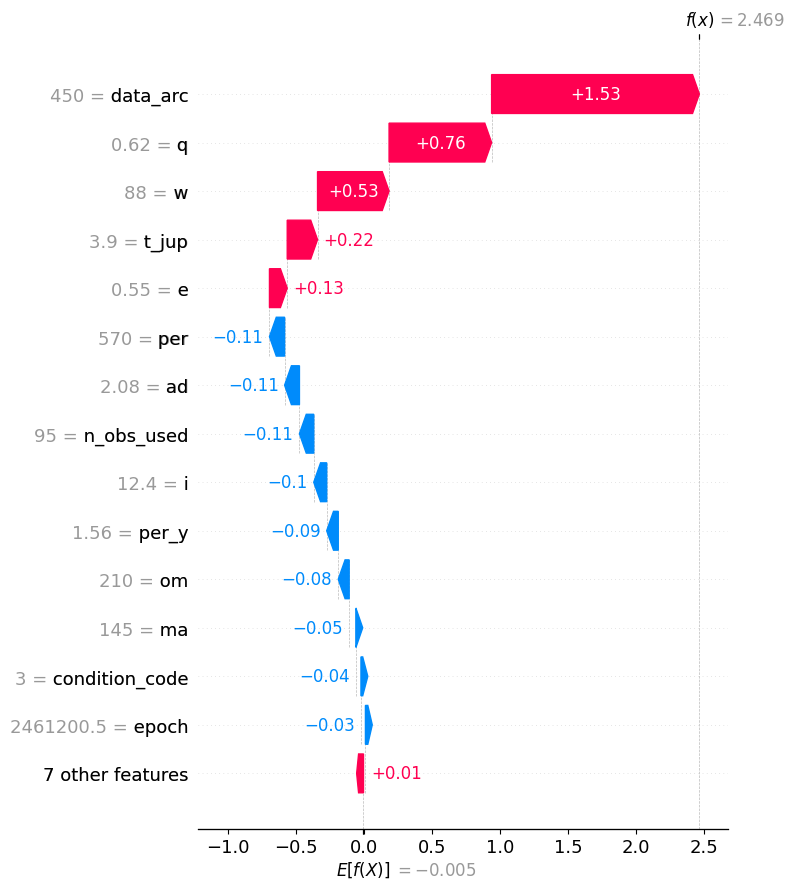

In [301]:
synthetic_shap = explainer.shap_values(synthetic_record)

explanation_synthetic = shap.Explanation(
    values=synthetic_shap[0],
    base_values=explainer.expected_value,
    data=synthetic_record.iloc[0],
    feature_names=synthetic_record.columns.tolist()
)

shap.plots.waterfall(explanation_synthetic, max_display=15, show=False)
plt.tight_layout()
plt.show()

Observations:
Predicted class: PHA. Predicted probability: 0.922.

Top drivers toward PHA: data_arc (+1.53), q (+0.76), w (+0.53). Minor negative pushes 
from per, ad, n_obs_used, i, per_y - all small (under -0.11 each).

Consistent with Sections 23a/23b: data_arc and q are again the two dominant features, 
matching their top ranking in the global SHAP summary and their strong influence in the 
true-positive example. This synthetic object mirrors the same "well tracked, low 
perihelion" pattern that drives the model's most confident PHA predictions.